In [1]:
# Import your libraries here

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import re
import requests
import time
from tqdm import tqdm
import torch
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

In [2]:
current_dir = os.path.abspath("")
project_root = os.path.abspath(os.path.join(current_dir, "../"))

if project_root not in sys.path:
    sys.path.append(project_root)

os.chdir(project_root)

print(f"Working directory set to: {os.getcwd()}")

Working directory set to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project


In [3]:
# Import your modules here
import importlib

import src.plotting_utils.plotting_utils as plot_utils
from src.data_pipeline_utils import data_fetching_handling as data_pipe
from src.data_pipeline_utils import edgar_scraping_utils as edgar_scrape
import src.nlp_utils.nlp_utils as nlp_utils

BASE_URL = "https://storage.googleapis.com/softuni_data_science_final_project_kamend1/static_data/"

importlib.reload(plot_utils)
importlib.reload(data_pipe)
importlib.reload(nlp_utils)

<module 'src.nlp_utils.nlp_utils' from 'D:\\users\\kamen.dimitrov\\desktop\\SOFTUNI\\AI_and_ML_upskill_program\\Data_Science\\08_final_project\\src\\nlp_utils\\nlp_utils.py'>

### Introduction and goal of this notebook

In this notebook, I will establish the process of researching and obtaining the second dataset. It will include text samples of the earnings press releases from earning announcement 8-K type reports and the management discussion and analysis (MD&A) sections of quarterly earning 10-Q type reports. 

**N.B.!** After I experienced the initial project setback by realizing it is not feasible to obtain actual earnings calls transcripts without breaching ethical and legal boundaries of data aggregators, I believe this is going to be the second best option. I will make a more detailed discussion on the possible presence of **Management Bias** in the text samples selected via this method and the possibility of it contaminating the scientific study and leading to inconclusive results from statistical standpoint.

**This notebook is optional** as I will directly provide the final dataset after all data handling and extraction operations. You can observe, or test, or directly run the notebook to reproduce the results.

The process includes:
- Obtain a history of filings for the group of selected companies
- Convert filing date to Pandas datetime
- Filter the required sample - in my case I will focus on filings after 2016-03-31, which currently is the last 10 years
- Use the Data column in the Data Frame to filter the 8-K reports, which contain earnings
- Scrape the EDGAR database to confirm that the ITEMS field on this record contains Item 2.02, which is the only indicator we have an 8-K report we need
- Scrape the EDGAR database to obtain Exhibit 99.1 press releases from the filtered 8-K reports and the MD&A sections from the 10-Q reports
- Verify I now have a full working dataset
- Utilize the services of Data Version Control (DVC) as the Data Set will likely be hundreds of megabites.

I would like to emphasize again that this notebook is only proof of concept and source of data obtaining and it remains optional to implement, as the next notebook will utilize the final product via DVC.

**Source of preliminary information** - [Calcbench filing filter](https://www.calcbench.com/filings?pg_classificationMethod=tickers&pg_tickers=AMD,GOOG,AAPL,T,BAC,CAT,CVX,CB,DE,XOM,FE,F,INTC,JNJ,JPM,LMT,MCD,MSFT,NKE,NVDA,ORCL,PFE,PG,CRM,TGT,UPS,VZ,V,WMT,DIS&pc_rangeOption=All%20History&f_filingTypes=BusinessWirePR_filedAfterAn8K&f_filingTypes=BusinessWirePR_replaced&f_filingTypes=proxy&f_filingTypes=annualQuarterlyReport&f_filingTypes=eightk_earningsPressRelease&f_filingTypes=eightk_guidanceUpdate&f_filingTypes=eightk_presentationSlides&f_filingTypes=eightk_monthlyOperatingMetrics&f_filingTypes=eightk_earningsPressRelease_preliminary&f_filingTypes=eightk_earningsPressRelease_correction&f_filingTypes=eightk_other&f_filingTypes=commentLetter&f_filingTypes=commentLetterResponse&f_filingTypes=eightk_nonfinancial&f_filingTypes=NT10KorQ&f_filingTypes=S&f_filingTypes=Four24B&f_filingTypes=institutionalOwnsership_13F&f_filingTypes=ForeignAnnualOrInterimReport) - Exported from Calcbench on 2026-03-31. 

Unfortunately, I have access to Calcbench through my CFA Institute member benefits. However, this particular Calbench service appears to be generally part of the free tier service provided by them, and the link above opens without authentication and can be used to obtain fresh data and perform the data extraction as explained in this notebook. The end goal is to actually have a list of tickers and to extract all the history of filings these public companies committed to the SEC under legal requirements. 

For the purpose of all data exercises regarding the central thesis of this project, I will use a **fixed dataset**, which will be available in Google Cloud Storage, where I will use a bucket with free access to view by all users. This notebook serves to explain the roadmap I went through in order to prepare the data, which I will use further down the road. 

It appears that clicking the above source, which requires no authentication, opens the most recent data extraction result. Calcbench is a legitimate and reputable data service provider, so I hope that the above link will remain functional for a protracted period of time and produce actual and current data for the selected group of stocks. 

What Calcbench does for me is provide the date of the filing and the link as a URL saved in a string format to the SEC's EDGAR database. This simply saves several hours of manual work in EDGAR itself. The same sample could be obtained using varying techniques with the [edgartools Python library](https://edgartools.readthedocs.io/en/latest).

In my case, this historical extract will be directly read from the static data folder, and afterwards, I will perform and explain the logic behind several data handling operations. This will narrow down the rows to under 2000, and afterwards, I will use web scraping techniques to collect the text data and store it in a file, which is going to be a source of data in the actual academic exercise in the following notebook. 

#### 1. So, let's extract the static data in a Data Frame

In [4]:
# As a reminder, I will declare the tickers variable as in the starting workbook 1_1
tickers = [
    "AAPL", "GOOG", "MSFT", "NVDA",
    "JPM", "BAC", "F", "UPS", "WMT", "TGT",
    "VZ", "T", "FE", "PFE", "JNJ", "DIS",
    "V", "MCD", "NKE", "XOM", "CVX",
    "CAT", "DE", "LMT", "AMD", "INTC", "ORCL", 
    "CRM", "CB", "PG"
]

# Extract the data from the calcbench CSV file
filing_data = pd.read_csv(BASE_URL + "calcbench_filings.csv", sep=';')

# Alternatively, you can save your new CSV file locally to static_data and read from there
# filing_data = pd.read_csv("static_data/calcbench_filings.csv", sep=';')

filing_data

,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data
0,2575776,ADVANCED MICRO DEVICES INC,AMD,2488,26.3.2026,DEF 14A,26.12.2025,2025.0,4.0,https://www.sec.gov/Archives/edgar/data/2488/0...,27.3.2026,False
1,2575712,Walmart Inc.,WMT,104169,26.3.2026,8-K,29.4.2026,2027.0,1.0,https://www.sec.gov/Archives/edgar/data/104169...,27.3.2026,False
2,2575404,FORD MOTOR CO,F,37996,26.3.2026,DEF 14A,30.12.2025,2025.0,4.0,https://www.sec.gov/Archives/edgar/data/37996/...,27.3.2026,False
3,2575170,CATERPILLAR INC,CAT,18230,25.3.2026,8-K,30.3.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/18230/...,26.3.2026,False
4,2574747,LOCKHEED MARTIN CORP,LMT,936468,25.3.2026,DEF 14A,30.12.2025,2025.0,4.0,https://www.sec.gov/Archives/edgar/data/936468...,26.3.2026,False
...,...,...,...,...,...,...,...,...,...,...,...,...
10946,1446319,Visa Inc.,V,1403161,3.2.2008,10-Q,30.12.2007,2008.0,1.0,https://www.sec.gov/Archives/edgar/data/140316...,4.2.2008,False
10947,1451590,PROCTER & GAMBLE Co,PG,80424,31.1.2008,10-Q,30.12.2007,2008.0,2.0,https://www.sec.gov/Archives/edgar/data/80424/...,1.2.2008,False
10948,1448087,Apple Inc,AAPL,320193,31.1.2008,10-Q,28.12.2007,2008.0,1.0,https://www.sec.gov/Archives/edgar/data/320193...,1.2.2008,False
10949,1451223,Microsoft Corp,MSFT,789019,23.1.2008,10-Q,30.12.2007,2008.0,2.0,https://www.sec.gov/Archives/edgar/data/789019...,24.1.2008,False


In [14]:
filing_data.shape

(10951, 12)

#### 2. Convert the date from a string format ot a Pandas datetime format

In [5]:
filing_data['Filing Date'] = pd.to_datetime(
    filing_data['Filing Date'],
    dayfirst=True,
    errors='coerce',
    )

filing_data['Calcbench Published'] = pd.to_datetime(
    filing_data['Calcbench Published'],
    dayfirst=True,
    errors='coerce',
    )

filing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10951 entries, 0 to 10950
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Filing ID            10951 non-null  int64         
 1   Company              10951 non-null  object        
 2   Ticker               10951 non-null  object        
 3   CIK                  10951 non-null  int64         
 4   Filing Date          10951 non-null  datetime64[ns]
 5   Filing Type          10947 non-null  object        
 6   Period End           10912 non-null  object        
 7   Fiscal Year          10897 non-null  float64       
 8   Fiscal Period        10903 non-null  float64       
 9   SEC Link             10951 non-null  object        
 10  Calcbench Published  10941 non-null  datetime64[ns]
 11  Data                 10951 non-null  bool          
dtypes: bool(1), datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 951.9+ KB


#### 3. Establish the logic of verifying we have the needed 8-K filings for the scraping operations

The cell below illustrates the logic used behined the first step of extracting the actual text data I need It is to check if have filtered correctly 8-K filings, which are indeed earnings announcements by containing item 2.02 under items. The EDGAR Requests will take a long time (close to half hour for the filtered Data Set) if I choose a standard sequential crawl with a 0.11s delay specifically to adhere to the SEC's Fair Access Policy. However, it looks like extracting data from SEC's EDGAR database has become a branch of Data Science on its own foundations. As many people have already sought to time-optimize data handling performance at the edge of the SEC limit of ten requests per second, I took ready examples of code snippets to assemble asynchronous methods with semaphor system and multiple workers to optimize time for data handling without being throtled down, receiving 429 responses or being outright banned by the SEC. I will verify that I have selected the necessary 8-K filings at the SEC for my sample. 

Afterwards, I will apply the [edgartools Python library](https://edgartools.readthedocs.io/en/latest/) to obtain the actual text samples as it will be shown below.

When using the code please define your own user agent to send as a header to SEC's EDGAR database.

In [16]:
test_url = "https://www.sec.gov/Archives/edgar/data/1341439/000119312526100148/0001193125-26-100148-index.htm"
headers = {'User-Agent': 'Kamen Dimitrov (kamendd@hotmail.com)'}

response = requests.get(test_url, headers=headers)
print(f"Status: {response.status_code}")

# Use a more robust regex that ignores extra spaces and HTML entities
pattern = r"Item\s*2\.02" 
match = re.search(pattern, response.text, re.IGNORECASE)

print(f"Match Found: {bool(match)}")

Status: 200
Match Found: True


#### 4. Run the first scraping operation to confirm we have the correct 8-K reports to finish this filtering data handling operation

Here is the actual data pipeline call, which implements the above illustration to all cells and thanks to the asynchronous capabilties developed in python, the particular Data Set will require 991 calls to the database, which are resolved in approximatelt 2 minutes. My first sequantial method took over 27 minutes, which prompted me to reasearch the async functionality (I have low familiarity with it), to take code snippets and finally ask the LLM's to iron out the bugs. 

In [6]:
# 1. Take filings only for the last 10 years
filing_data = filing_data[filing_data['Filing Date'] >= '2016-03-01'].reset_index(drop=True)

# 2. We are looking only for 8-K Earnings and 10-Q quarterly financial statements
filing_data['is_applicable_type'] = filing_data['Filing Type'].str.contains('8-K|10-Q', case=False, na=False)
filing_data = filing_data[filing_data['is_applicable_type'] == True].drop(columns=['is_applicable_type'])

# 3. The Calcbench raw data contains True in the 'Data' Field if it is an 8-K earnings report
filing_data = filing_data[filing_data['Data'] == True].copy()

# 4. We are down to 1891 rows. We need to scrape the EDGAR database to ascertain that the Items field in this filing contains 2.02,
#which means that is what we need and it will contain a press-release under EX-99.1
filing_data['is_verified_signal'] = pd.NA
print(f"Total rows: {len(filing_data)}")
print(f"Number of 8-Ks: {len(filing_data[filing_data['Filing Type'] == '8-K'])}")

#The code below is expected to run for around 2 minutes of runtime
results = await edgar_scrape.run_compliance_batch(filing_data)
filing_data['is_verified_signal'] = results

# 5. Save the data to a CSV file
filing_data.to_csv("static_data/filing_data_verified_8_K.csv", index=False)

filing_data

Total rows: 1894
Number of 8-Ks: 991
Starting SEC Compliance Check... this will take a few minutes.


,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal
26,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True
42,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True
45,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True
46,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True
56,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6587,350128,JPMORGAN CHASE & CO,JPM,19617,2016-04-12,8-K,30.3.2016,2016.0,1.0,http://www.sec.gov/Archives/edgar/data/19617/0...,2016-04-13,True,True
6602,349344,NIKE INC,NKE,320187,2016-04-05,10-Q,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/320187/...,2016-04-05,True,True
6627,346950,NIKE INC,NKE,320187,2016-03-21,8-K,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/320187/...,2016-03-22,True,True
6630,346679,ORACLE CORP,ORCL,1341439,2016-03-18,10-Q,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/1341439...,2016-03-18,True,True


#### 5. Let's do additional handling and save the result in a CSV file, which I will leave in static data

In [10]:
# In the previous step, we saved a file. Let's read it again
# The active code will read the already created file in Google Cloud Storage
filing_data = pd.read_csv(BASE_URL + "filing_data_verified_8_K.csv")

# Alternatively, from our local static_data  folder to follow the original path
# filing_data = pd.read_csv("static_data/filing_data_verified_8_K.csv")

# 1. Drop the remaining N/A values where Exhibit 99.1 was not identified.
filing_data = filing_data[filing_data['is_verified_signal'] == True].copy()

# 2. Let's extract part of the SEC Link URL known in the EDGAR database as the accession number
filing_data['accession'] = filing_data['SEC Link'].apply(edgar_scrape.extract_accession_number)

# 3. Establish the number of datapoints in the final sample. I remain with 1879 rows for my 30 tickers.
print(filing_data['is_verified_signal'].value_counts())
print(filing_data.info())

# 3. Save the data again to a CSV file
filing_data.to_csv("static_data/filing_data_verified_8_K_ready_to_extract_text.csv", index=False)

is_verified_signal
True    1879
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 1879 entries, 0 to 1893
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Filing ID            1879 non-null   int64  
 1   Company              1879 non-null   object 
 2   Ticker               1879 non-null   object 
 3   CIK                  1879 non-null   int64  
 4   Filing Date          1879 non-null   object 
 5   Filing Type          1879 non-null   object 
 6   Period End           1879 non-null   object 
 7   Fiscal Year          1879 non-null   float64
 8   Fiscal Period        1879 non-null   float64
 9   SEC Link             1879 non-null   object 
 10  Calcbench Published  1879 non-null   object 
 11  Data                 1879 non-null   bool   
 12  is_verified_signal   1879 non-null   bool   
 13  accession            1879 non-null   object 
dtypes: bool(2), float64(2), int64(2), o

In [11]:
verified_filing_data = pd.read_csv(BASE_URL + "filing_data_verified_8_K_ready_to_extract_text.csv")

#Alternatively, to follow the original path for reproduction purposes
# verified_filing_data = pd.read_csv("static_data/filing_data_verified_8_K_ready_to_extract_text.csv")

verified_filing_data

,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal,accession
0,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True,0001193125-26-101045
1,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True,0001104659-26-020158
2,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True,0001045810-26-000019
3,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True,0001108524-26-000056
4,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True,0000104169-26-000032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1874,350128,JPMORGAN CHASE & CO,JPM,19617,2016-04-12,8-K,30.3.2016,2016.0,1.0,http://www.sec.gov/Archives/edgar/data/19617/0...,2016-04-13,True,True,0000019617-16-000950
1875,349344,NIKE INC,NKE,320187,2016-04-05,10-Q,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/320187/...,2016-04-05,True,True,0000320187-16-000264
1876,346950,NIKE INC,NKE,320187,2016-03-21,8-K,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/320187/...,2016-03-22,True,True,0000320187-16-000257
1877,346679,ORACLE CORP,ORCL,1341439,2016-03-18,10-Q,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/1341439...,2016-03-18,True,True,0001193125-16-510333


#### 6. Text extraction from EDGAR using the Python library `edgartools`

##### 6.1. Take a sample of the data and perform test data extraction 
This phase utilizes `edgartools` to isolate the narrative sections from different SEC filing types. This will provide the dataset to be fed into FinBERT in attempt to obtain financial sentiment.

The extraction logic is:

- **Accession Mapping:** `extract_accession_number` parses the SEC URLs from the raw dataset to isolate the unique Accession Number, which is a direct key to fetch specific filings from the EDGAR database.

- **Filing-Specific Routing:** `process_filing_row` acts as the logic gate, which identifies the Filing Type to determine whether to apply a method to pull from a 10-Q (Quarterly Report) or an 8-K (Current Report) according to their specifics.

- **10-Q (MD&A):** `extract_mdna_text` targets Item 2, the Management’s Discussion and Analysis from the body of the filing. This section contains the company’s qualitative view on financial condition and results of operations.

- **8-K (Press Releases):** `extract_press_release` attempts to fetch Exhibit 99.1 from the 8-K SEC filing. The Press Release text is expected to provide a sentiment-rich narrative regarding the company's earnings.

- **Validation:** All methods implement error handling to return pd.NA for empty or inaccessible filings in order to maintain the integrity of the final static dataset.

Below is a sample of five 10-Q and five 8-K reports, which should be extracted for **around 2 minutes.** The actual processing of the 1879 lines remaining after cleaning methods takes at least 6.5 hours and is prone to multiple time-outs and outages. I did extract the data like this; however, it will be provided as a ready, finalized Data Set. The code to extract it remains in cells below in a commented state.

In [12]:
test_sample = pd.concat([
    verified_filing_data[verified_filing_data['Filing Type'] == '10-Q'].head(5),
    verified_filing_data[verified_filing_data['Filing Type'] == '8-K'].head(5)
]).reset_index(drop=True)

tqdm.pandas(desc="SEC Extraction Progress")

start_time = time.perf_counter()
test_sample['text_output'] = test_sample.progress_apply(edgar_scrape.process_filing_row, axis=1)
end_time = time.perf_counter()
duration = end_time - start_time
print(f"Operation completed in {duration:.4f} seconds")

test_sample

SEC Extraction Progress: 100%|█████████████████████████████████████████████████████████| 10/10 [02:07<00:00, 12.75s/it]

Operation completed in 127.5140 seconds


,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal,accession,text_output
0,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True,0001193125-26-101045,Item 2. \tManagement’s Discussion and Analysis...
1,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True,0001104659-26-020158,Item 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...
2,2552121,Walt Disney Co,DIS,1744489,2026-02-01,10-Q,26.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/174448...,2026-02-02,True,True,0001744489-26-000019,MANAGEMENT’S DISCUSSION AND ANALYSIS OF\n\nFIN...
3,2551537,Apple Inc.,AAPL,320193,2026-01-29,10-Q,26.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/320193...,2026-01-30,True,True,0000320193-26-000006,Item 2. Management’s Discussion and Analysi...
4,2551531,VISA INC.,V,1403161,2026-01-29,10-Q,30.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/140316...,2026-01-30,True,True,0001403161-26-000045,Table of Contents\n\nITEM 2.Management’s Discu...
5,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True,0001045810-26-000019,Document\n\nNVIDIA Announces Financial Results...
6,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True,0001108524-26-000056,Document\n\nExhibit 99.1\n\nSalesforce Deliver...
7,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True,0000104169-26-000032,Document\n\n\n ...
8,2559317,DEERE & CO,DE,315189,2026-02-18,8-K,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-19,True,True,0001104659-26-017239,Exhibit 99.1\n(Furnished herewith)\n​\n\n\nNew...
9,2558457,FIRSTENERGY CORP,FE,1031296,2026-02-16,8-K,30.12.2025,2025.0,4.0,https://www.sec.gov/Archives/edgar/data/103129...,2026-02-17,True,True,0001031296-26-000041,Document\n\nExhibit 99.1\n\n\nFirstEnergy Corp...


In [14]:
test_sample['text_output'].str.len()

0     84701
1      7851
2     41492
3     17841
4     27532
5     60163
6     81024
7    112958
8     79114
9     28913
Name: text_output, dtype: int64

In [15]:
test_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Filing ID            10 non-null     int64  
 1   Company              10 non-null     object 
 2   Ticker               10 non-null     object 
 3   CIK                  10 non-null     int64  
 4   Filing Date          10 non-null     object 
 5   Filing Type          10 non-null     object 
 6   Period End           10 non-null     object 
 7   Fiscal Year          10 non-null     float64
 8   Fiscal Period        10 non-null     float64
 9   SEC Link             10 non-null     object 
 10  Calcbench Published  10 non-null     object 
 11  Data                 10 non-null     bool   
 12  is_verified_signal   10 non-null     bool   
 13  accession            10 non-null     object 
 14  text_output          10 non-null     object 
dtypes: bool(2), float64(2), int64(2), object(9)

##### 6.2 After confirming successful tests, we proceed with the actual data extraction

I will split the operation into four distinct steps. The step with the actual text data extraction from the SEC's EDGAR Database will be under comment and will be executable only if uncommented. The operation takes between 6.5 and 8 hours, utilizing the methods I have defined in my `edgar_scraping_utils` file. The process is separated into batches as it is prone to signal interruptions, occasional time-outs, etc. The methods are based on the capabilities of the `edgartools` library in Python.

The steps are as follows  (commented code to prevent activation without intent. The downloaded data is available separately):

1. Set up before performing the actual data extraction
2. Performing the actual data extraction in batches of 120 rows
3. Assemble the batches in a Data Set and save locally
4. Remove temporary files from local storage

In [19]:
# # 1. Set up prior to performing the actual data extraction

TEMP_DIR = "temp_chunks"
FINAL_OUTPUT = "static_data/verified_filing_data_with_text_output.csv"
BATCH_SIZE = 120

# os.makedirs(TEMP_DIR, exist_ok=True)
# os.makedirs("static_data", exist_ok=True)

# if 'text_output' not in verified_filing_data.columns:
#     verified_filing_data['text_output'] = pd.NA
# if 'extraction_status' not in verified_filing_data.columns:
#     verified_filing_data['extraction_status'] = 'PENDING'

# pending_df = verified_filing_data[verified_filing_data['extraction_status'] == 'PENDING']
# total_pending = len(pending_df)
# print(f"Total pending rows to be processed: {total_pending})")

In [13]:
# 2. Performing the actual data extraction in batches
# print(f"Starting extraction for {total_pending} rows...")

# if total_pending > 0:
#     with tqdm(total=total_pending, desc="Processing Chunks") as pbar:
#         for i in range(0, total_pending, BATCH_SIZE):
#             batch = pending_df.iloc[i:i + BATCH_SIZE].copy()
#             chunk_filename = f"{TEMP_DIR}/chunk_{i}_to_{i + len(batch)}.csv"

#             if os.path.exists(chunk_filename):
#                 pbar.update(len(batch))
#                 continue

#             try:
#                 extracted_texts = batch.apply(edgar_scrape.process_filing_row, axis=1)
#                 batch['text_output'] = extracted_texts
#                 batch['extraction_status'] = extracted_texts.apply(
#                     lambda x: 'SUCCESS' if pd.notna(x) and str(x).strip() != '' else 'FAILED'
#                 )

#                 batch.to_csv(chunk_filename, index=False)

#                 pbar.update(len(batch))

#             except Exception as e:
#                 print(f"\nCRITICAL ERROR on chunk {i}. Error: {e}")
#                 print("Halting extraction. Previous chunks are safe in the temp folder.")
#                 break

Starting extraction for 1879 rows...


Processing Chunks:   0%|                                                                      | 0/1879 [00:00<?, ?it/s]TenQ falling back to legacy parser for 'Item 2' (filing: 0000063908-18-000025). New parser sections available: ['part_ii_item_15', 'part_i_quantitative_and_qualitative_disclosures_about_market_risk', 'part_i_item_8', 'part_ii_item_3']. This fallback will be removed in v6.0.
TenQ falling back to legacy parser for 'Item 2' (filing: 0000034088-18-000024). New parser sections available: ['part_ii_item_1', 'part_i_item_3', 'part_ii_item_6']. This fallback will be removed in v6.0.
TenQ falling back to legacy parser for 'Item 2' (filing: 0000070858-18-000020). New parser sections available: ['Mortgage Banking Risk Management', 'Item 1', 'Signature', 'Item 1A', 'Managing Risk', 'Liquidity Risk', 'Consumer Portfolio Credit Risk Management', 'Market Risk Management', 'Credit Risk Management', 'Interest Rate Risk Management for the Banking Book', 'Item 8', 'Trading Risk Managemen

In [14]:
# 3. Assemble the batches in a Data Set and save locally

# print("\nInitiating Gather Phase...")

# chunk_files = glob.glob(f"{TEMP_DIR}/*.csv")

# if not chunk_files:
#     print("No chunks found to merge.")
# else:
#     df_list = [pd.read_csv(file) for file in chunk_files]
#     final_df = pd.concat(df_list, ignore_index=True)

#     final_df.to_csv(FINAL_OUTPUT, index=False)
#     print(f"Successfully merged {len(chunk_files)} chunks into {FINAL_OUTPUT}.")
#     print(f"Total rows in final dataset: {len(final_df)}")


Initiating Gather Phase...
Successfully merged 16 chunks into static_data/verified_filing_data_with_text_output.csv.
Total rows in final dataset: 1879


In [22]:
# 4. Remove temporary files from local storage
# final_df = pd.read_csv("static_data/verified_filing_data_with_text_output.csv")

# if len(final_df) == len(verified_filing_data):
#     print("\nData validation passed: Final dataset matches the original row count.")
#     try:
#         shutil.rmtree(TEMP_DIR)
#         print(f"Successfully deleted the temporary directory: {TEMP_DIR}")

#     except Exception as e:
#         print(f"Warning: Could not delete {TEMP_DIR}. Error: {e}")

# else:
#     print("\nWARNING: Data validation failed!")
#     print(f"Original dataset had {len(verified_filing_data)} rows.")
#     print(f"Merged dataset has {len(final_df)} rows.")
#     print(f"The temporary folder '{TEMP_DIR}' was NOT deleted. Please inspect the chunks.")


Data validation passed: Final dataset matches the original row count.
Successfully deleted the temporary directory: temp_chunks


#### 7. Text output cleanup

##### Data Cleaning for Sentiment Analysis
To ensure the FinBERT model processes the SEC 8-K filing press releases and the 10-Q MD&A sections accurately, the following structural cleaning is performed:

- HTML Decoding: Uses `html.unescape` to convert entities (like `&nbsp;`) into standard characters, preventing tokenization errors and wasting the 512-token budgets on HTML artifacts, possibly diluting the score and expanding the processing time.

- Table Suppression: Employs regex to identify and remove blocks of numerical data. This prevents non-narrative financial tables from diluting the sentiment score toward "Neutral."

- Whitespace Normalization: Collapses erratic line breaks, tabs, and multiple spaces into single spaces. This maximizes information density within the model's 512-token limit.

- Context Preservation: Unlike traditional NLP, this method retains casing, punctuation, and stopwords (e.g., "not," "no"), which are critical for the transformer model to understand financial negation and tone.

In [4]:
verified_filing_data_with_text_output = pd.read_csv(BASE_URL + "verified_filing_data_with_text_output.csv")
verified_filing_data_with_text_output

,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal,accession,text_output,extraction_status
0,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True,0001193125-26-101045,Item 2. \tManagement’s Discussion and Analysis...,SUCCESS
1,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True,0001104659-26-020158,Item 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,SUCCESS
2,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True,0001045810-26-000019,Document\n\nNVIDIA Announces Financial Results...,SUCCESS
3,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True,0001108524-26-000056,Document\n\nExhibit 99.1\n\nSalesforce Deliver...,SUCCESS
4,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True,0000104169-26-000032,Document\n\n\n ...,SUCCESS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1874,1568535,TARGET CORP,TGT,27419,2020-05-19,8-K,1.5.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/27419/...,2020-05-20,True,True,0000027419-20-000011,"Document\n\nExhibit (99)\n\n<img alt=""releaseb...",SUCCESS
1875,1568023,Walmart Inc.,WMT,104169,2020-05-18,8-K,29.4.2020,2021.0,1.0,https://www.sec.gov/Archives/edgar/data/104169...,2020-05-19,True,True,0000104169-20-000016,"Exhibit\n\n\n<img alt=""image40a02a01a21.jpg"" s...",SUCCESS
1876,1560989,UNITED PARCEL SERVICE INC,UPS,1090727,2020-05-07,10-Q,30.3.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/109072...,2020-05-08,True,True,0001090727-20-000023,Table of Contents\n\nItem 2.Management’s Discu...,SUCCESS
1877,1559527,JPMORGAN CHASE & CO,JPM,19617,2020-05-06,10-Q,30.3.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/19617/...,2020-05-07,True,True,0000019617-20-000299,INTRODUCTION\n\nThe following is Management’s ...,SUCCESS


In [7]:
total_rows = len(verified_filing_data_with_text_output)
nan_count = verified_filing_data_with_text_output['text_output'].isna().sum()

print(f"Total rows with failed EGAR extraction: {nan_count}")
print(f"Percentage failed rows {(nan_count * 100 / total_rows):.2f}%")

Total rows with failed EGAR extraction: 84
Percentage failed rows 4.47%


Raw Text Description #TODO

In [8]:
text_len = pd.DataFrame(verified_filing_data_with_text_output['text_output'].str.len())
text_len.describe().T

,count,mean,std,min,25%,50%,75%,max
text_output,1795.0,78568.885794,94162.084036,181.0,35376.5,57368.0,83450.5,711306.0


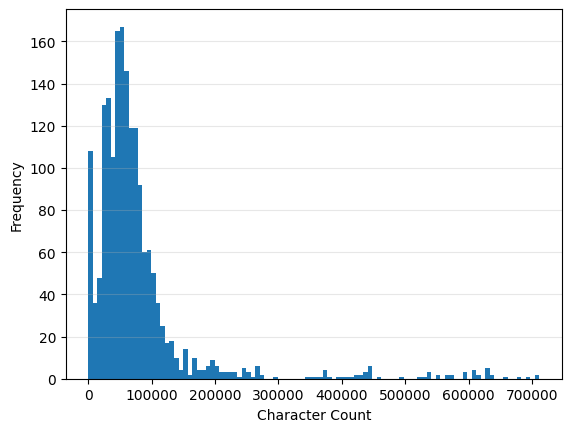

In [21]:
plt.hist(text_len, bins=100)
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

Show Histogram and explain #TODO

In [12]:
verified_filing_data_clean = verified_filing_data_with_text_output.dropna(subset=['text_output']).copy()
text_len = pd.DataFrame(verified_filing_data_clean['text_output'].str.len())
text_len.describe().T

,count,mean,std,min,25%,50%,75%,max
text_output,1795.0,78568.885794,94162.084036,181.0,35376.5,57368.0,83450.5,711306.0


In [22]:
verified_filing_data_clean['cleaned_text'] = (
    verified_filing_data_clean['text_output']
    .apply(nlp_utils.clean_for_finbert)
)

verified_filing_data_clean.to_csv("static_data/verified_filing_data_clean_text.csv", index=False)

In [18]:
clean_text_len = pd.DataFrame(verified_filing_data_clean['cleaned_text'].str.len())
clean_text_len.describe().T

,count,mean,std,min,25%,50%,75%,max
cleaned_text,1795.0,56789.223398,79587.198575,179.0,23562.5,37847.0,60613.0,678581.0


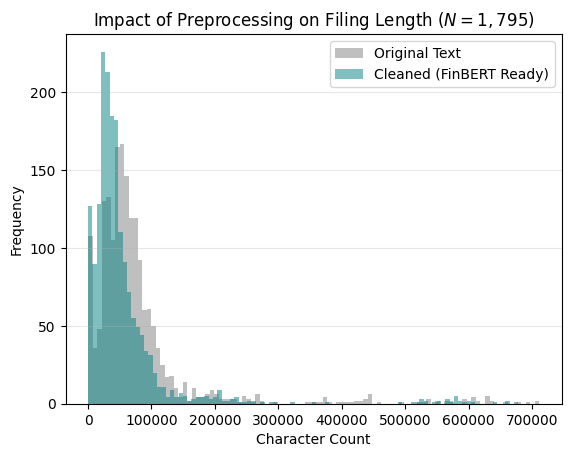

In [20]:
plt.hist(text_len, bins=100, alpha=0.5, label='Original Text', color='gray')
plt.hist(clean_text_len, bins=100, alpha=0.5, label='Cleaned (FinBERT Ready)', color='teal')
plt.title('Impact of Preprocessing on Filing Length')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.show()

#### 8. NLP text processing Source

For sentiment extraction, I utilized FinBERT (Araci, 2019), a domain-specific transformer model based on the BERT architecture. Unlike general-purpose language models, FinBERT was pre-trained on a massive corpus of financial communications, allowing it to accurately decode the nuanced language and 'tone' of corporate disclosures where standard models often fail.

Developed by Google in 2018, BERT (Bidirectional Encoder Representations from Transformers) improved natural language processing significantly when introduced.

#### 9. Methodology & Model Choice
To analyze the "Hard Data" provided in this repository, I utilized the **FinBERT** (`ProsusAI/finbert`) model—a pre-trained Natural Language Processing (NLP) model specifically fine-tuned for financial sentiment.

* **Task:** Classification of around 1700 unique texts 
* **Processing:** Each text (avg. 7,333 tokens) will be split into overlapping 512-token chunks.
* **Aggregation:** The final score will be the mean average of all chunks within a single transcript, providing a global sentiment value between -1 (Bearish) and 1 (Bullish).

The cell below will provide an example of what I intend to do.

##### 9.1. Computational Hardware & Performance
Deep learning on large text blocks is computationally expensive. The results provided here will be generated using **GPU Acceleration** to ensure efficiency.

##### 9.2. **Benchmark Comparison**
If you choose to recalculate these scores using the provided script, please be aware of the following estimated processing times:

| Environment | Device Type | Avg. Time per Score | Total Time (280) |
| :--- | :--- | :--- | :--- |
| **Standard Laptop** | Intel/AMD CPU | ~33.3 seconds | **~3.5 to 4 Hours** |
| **High-End PC** | NVIDIA GPU (CUDA) | ~0.5 seconds | **~5 to 7 Minutes** |
| **Cloud (Google Colab)** | Tesla T4 GPU | ~0.4 seconds | **~4 Minutes** |

> **Instruction:** If running on a "regular" machine (CPU), ensure the laptop is plugged into a power source and "Sleep Mode" is disabled. The fans will likely run at maximum speed during this process.

Let's see the example cell:

In [24]:
# We will utilize a test sample dataframe for the illustration of the method implementation
verified_filing_data_clean_text = pd.read_csv(BASE_URL + "verified_filing_data_clean_text.csv")

test_sample_1 = pd.concat([
    verified_filing_data_clean_text[verified_filing_data_clean_text['Filing Type'] == '10-Q'].head(5),
    verified_filing_data_clean_text[verified_filing_data_clean_text['Filing Type'] == '8-K'].head(5)
]).reset_index(drop=True)

model_name = "ProsusAI/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, ignore_mismatched_sizes=True)

device = 0 if torch.cuda.is_available() else -1 
nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

sentiment_results = []

for i, row in test_sample_1.iterrows():
    try:

        chunks = nlp_utils.classify_long_transcript_batched(row['cleaned_text'], tokenizer, nlp)
        score = nlp_utils.aggregate_sentiment(chunks)

        sentiment_results.append(score)

    except Exception as e:
        print(f"Error at row {i}: {e}")
        sentiment_results.append(0)


test_sample_1['sentiment_score'] = sentiment_results
# verified_filing_data_clean_text.to_csv('final_dataset_with_sentiment.csv', index=False)
test_sample_1

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal,accession,text_output,extraction_status,cleaned_text,sentiment_score
0,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True,0001193125-26-101045,Item 2. \tManagement’s Discussion and Analysis...,SUCCESS,Item 2. Management’s Discussion and Analysis o...,-0.005772
1,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True,0001104659-26-020158,Item 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,SUCCESS,Item 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,-0.806065
2,2552121,Walt Disney Co,DIS,1744489,2026-02-01,10-Q,26.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/174448...,2026-02-02,True,True,0001744489-26-000019,MANAGEMENT’S DISCUSSION AND ANALYSIS OF\n\nFIN...,SUCCESS,MANAGEMENT’S DISCUSSION AND ANALYSIS OF FINANC...,-0.049975
3,2551537,Apple Inc.,AAPL,320193,2026-01-29,10-Q,26.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/320193...,2026-01-30,True,True,0000320193-26-000006,Item 2. Management’s Discussion and Analysi...,SUCCESS,Item 2. Management’s Discussion and Analysis o...,-0.406248
4,2551531,VISA INC.,V,1403161,2026-01-29,10-Q,30.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/140316...,2026-01-30,True,True,0001403161-26-000045,Table of Contents\n\nITEM 2.Management’s Discu...,SUCCESS,Table of Contents ITEM 2.Management’s Discussi...,0.057300
5,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True,0001045810-26-000019,Document\n\nNVIDIA Announces Financial Results...,SUCCESS,Document NVIDIA Announces Financial Results fo...,0.279819
6,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True,0001108524-26-000056,Document\n\nExhibit 99.1\n\nSalesforce Deliver...,SUCCESS,Document Exhibit 99.1 Salesforce Delivers Reco...,0.118013
7,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True,0000104169-26-000032,Document\n\n\n ...,SUCCESS,Document Walmart reports Q4 results •Revenue g...,0.136180
8,2559317,DEERE & CO,DE,315189,2026-02-18,8-K,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-19,True,True,0001104659-26-017239,Exhibit 99.1\n(Furnished herewith)\n​\n\n\nNew...,SUCCESS,Exhibit 99.1 (Furnished herewith) ​ News Relea...,-0.031144
9,2558457,FIRSTENERGY CORP,FE,1031296,2026-02-16,8-K,30.12.2025,2025.0,4.0,https://www.sec.gov/Archives/edgar/data/103129...,2026-02-17,True,True,0001031296-26-000041,Document\n\nExhibit 99.1\n\n\nFirstEnergy Corp...,SUCCESS,Document Exhibit 99.1 FirstEnergy Corp. For Re...,0.237013


Below is the code to run sentiment scoring on the full dataset. I ran it to complete the data set. However, I used T4 runtime in Google Colab to process the data in under 1 hour. I will leave the code commented, while the calculated data is available with the repo on Google Cloude Storage.

In [ ]:
# The code to obtain sentiment scores on all rows in the dataset. I will leave in commented state.

# verified_filing_data_clean_text = pd.read_csv(BASE_URL + "verified_filing_data_clean_text.csv")

# model_name = "ProsusAI/finbert"
# tokenizer = BertTokenizer.from_pretrained(model_name)
# model = BertForSequenceClassification.from_pretrained(model_name, ignore_mismatched_sizes=True)

# device = 0 if torch.cuda.is_available() else -1 
# nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

# sentiment_results = []
# checkpoint_path = 'static_data/final_dataset_with_sentiment_checkpoint.csv', index=False)

# for i, row in tqdm(verified_filing_data_clean_text.iterrows(), total=len(verified_filing_data_clean_text)):
#     try:
#         text_input = str(row['cleaned_text']) if pd.notnull(row['cleaned_text']) else ""

#         if text_input.strip() == "":
#             sentiment_results.append(0)
#             continue

#         chunks = nlp_utils.classify_long_transcript_batched(text_input, tokenizer, nlp)
#         score = nlp_utils.aggregate_sentiment(chunks)
#         sentiment_results.append(score)

#     except Exception as e:
#         print(f"Error at row {i}: {e}")
#         sentiment_results.append(0)

#     if (i + 1) % 100 == 0:
#         # Temporary save so you don't lose progress
#         temp_df = verified_filing_data_clean_text.iloc[:len(sentiment_results)].copy()
#         temp_df['sentiment_score'] = sentiment_results
#         temp_df.to_csv(checkpoint_path, index=False)


# verified_filing_data_clean_text['sentiment_score'] = sentiment_results
# verified_filing_data_clean_text.to_csv('static_data/final_dataset_with_sentiment.csv', index=False)
# verified_filing_data_clean_text

#### 10. Let's now see what reports are available for different stocks.

In [25]:
final_dataset_with_sentiment = pd.read_csv(BASE_URL + "final_dataset_with_sentiment.csv")
final_dataset_with_sentiment

,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal,accession,extraction_status,sentiment_score
0,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True,0001193125-26-101045,SUCCESS,-0.005772
1,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True,0001104659-26-020158,SUCCESS,-0.806066
2,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True,0001045810-26-000019,SUCCESS,0.279819
3,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True,0001108524-26-000056,SUCCESS,0.118013
4,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True,0000104169-26-000032,SUCCESS,0.136180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790,1568535,TARGET CORP,TGT,27419,2020-05-19,8-K,1.5.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/27419/...,2020-05-20,True,True,0000027419-20-000011,SUCCESS,-0.130304
1791,1568023,Walmart Inc.,WMT,104169,2020-05-18,8-K,29.4.2020,2021.0,1.0,https://www.sec.gov/Archives/edgar/data/104169...,2020-05-19,True,True,0000104169-20-000016,SUCCESS,0.156512
1792,1560989,UNITED PARCEL SERVICE INC,UPS,1090727,2020-05-07,10-Q,30.3.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/109072...,2020-05-08,True,True,0001090727-20-000023,SUCCESS,-0.495376
1793,1559527,JPMORGAN CHASE & CO,JPM,19617,2020-05-06,10-Q,30.3.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/19617/...,2020-05-07,True,True,0000019617-20-000299,SUCCESS,-0.010477


Let's explore the sentiment score

In [26]:
pd.DataFrame(final_dataset_with_sentiment['sentiment_score']).describe().T

,count,mean,std,min,25%,50%,75%,max
sentiment_score,1795.0,-0.044907,0.199955,-0.965393,-0.152236,-0.009752,0.078337,0.604251


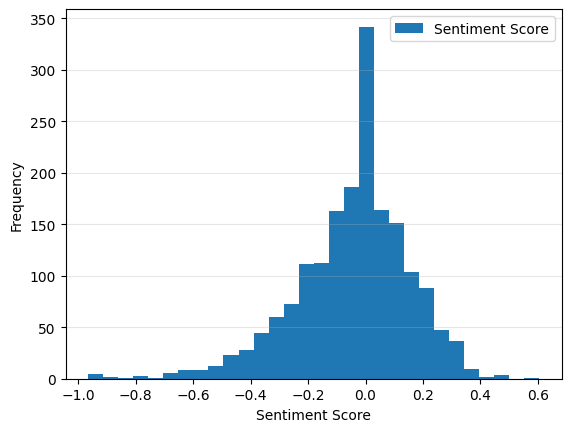

In [29]:
plt.hist(final_dataset_with_sentiment['sentiment_score'], bins=30, label = 'Sentiment Score')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

I would like to obtain industry and sector information from yfinance for each represented stock

### Conlusion

#TODO